# Comparison of two patches by base colour

Visualize data

In [14]:
from pathlib import Path

siamese_train_dir = Path.home() / "Documents" / "siamese_dataset" / "Train"
subfolders = ["clean", "faulty"]

for subfolder in subfolders:
    root = siamese_train_dir / subfolder
    print(f"\n[{subfolder.upper()}]")

    if subfolder == "faulty":
        for color_folder in sorted(root.glob("faulty_*")):
            if color_folder.is_dir():
                sub_subfolders = list(color_folder.iterdir())

                # Handle folders with nested fault types (e.g., dead, mixed)
                if any(sub.is_dir() for sub in sub_subfolders):
                    for fault_type in sorted(sub_subfolders):
                        if fault_type.is_dir():
                            count = len(list(fault_type.glob("*.jpg")))
                            print(f"{color_folder.name}/{fault_type.name}: {count} images")

                # Handle folders like faulty_blackout with direct image files
                else:
                    count = len(list(color_folder.glob("*.jpg")))
                    print(f"{color_folder.name}: {count} images")

    else:
        for color_folder in sorted(root.glob("clean_*")):
            if color_folder.is_dir():
                count = len(list(color_folder.glob("*.jpg")))
                print(f"{color_folder.name}: {count} images")


[CLEAN]
clean_blue: 80 images
clean_cyan: 70 images
clean_green: 80 images
clean_orange: 70 images
clean_pink: 80 images
clean_red: 70 images
clean_white: 70 images
clean_yellow: 70 images

[FAULTY]
faulty_blackout: 102 images
faulty_blue/1_coloured_key_blue: 30 images
faulty_blue/dead_blue: 24 images
faulty_blue/mixed: 4 images
faulty_cyan/1_coloured_key_cyan: 30 images
faulty_cyan/dead_cyan: 15 images
faulty_cyan/mixed: 4 images
faulty_green/1_coloured_key_green: 30 images
faulty_green/dead_green: 15 images
faulty_green/mixed: 4 images
faulty_orange/1_coloured_key_orange: 30 images
faulty_orange/dead_orange: 15 images
faulty_orange/mixed: 4 images
faulty_pink/1_coloured_key_pink: 30 images
faulty_pink/dead_pink: 15 images
faulty_pink/mixed: 4 images
faulty_red/1_coloured_key_red: 30 images
faulty_red/dead_red: 15 images
faulty_red/mixed: 4 images
faulty_white/1_coloured_key_white: 30 images
faulty_white/dead_white: 15 images
faulty_white/mixed: 7 images
faulty_yellow/1_coloured_key_

In [15]:
from pathlib import Path

siamese_train_dir = Path.home() / "Documents" / "siamese_dataset" / "Val"
subfolders = ["clean", "faulty"]

for subfolder in subfolders:
    root = siamese_train_dir / subfolder
    print(f"\n[{subfolder.upper()}]")

    if subfolder == "faulty":
        for color_folder in sorted(root.glob("faulty_*")):
            if color_folder.is_dir():
                sub_subfolders = list(color_folder.iterdir())

                # Handle folders with nested fault types (e.g., dead, mixed)
                if any(sub.is_dir() for sub in sub_subfolders):
                    for fault_type in sorted(sub_subfolders):
                        if fault_type.is_dir():
                            count = len(list(fault_type.glob("*.jpg")))
                            print(f"{color_folder.name}/{fault_type.name}: {count} images")

                # Handle folders like faulty_blackout with direct image files
                else:
                    count = len(list(color_folder.glob("*.jpg")))
                    print(f"{color_folder.name}: {count} images")

    else:
        for color_folder in sorted(root.glob("clean_*")):
            if color_folder.is_dir():
                count = len(list(color_folder.glob("*.jpg")))
                print(f"{color_folder.name}: {count} images")


[CLEAN]
clean_blue: 40 images
clean_cyan: 38 images
clean_green: 40 images
clean_orange: 38 images
clean_pink: 40 images
clean_red: 38 images
clean_white: 38 images
clean_yellow: 38 images

[FAULTY]
faulty_blackout: 36 images
faulty_blue/1_coloured_key_blue: 12 images
faulty_blue/dead_blue: 9 images
faulty_blue/mixed: 2 images
faulty_cyan/1_coloured_key_cyan: 12 images
faulty_cyan/dead_cyan: 9 images
faulty_cyan/mixed: 2 images
faulty_green/1_coloured_key_green: 12 images
faulty_green/dead_green: 9 images
faulty_green/mixed: 2 images
faulty_orange/1_coloured_key_orange: 12 images
faulty_orange/dead_orange: 9 images
faulty_orange/mixed: 2 images
faulty_pink/1_coloured_key_pink: 12 images
faulty_pink/dead_pink: 9 images
faulty_pink/mixed: 2 images
faulty_red/1_coloured_key_red: 12 images
faulty_red/dead_red: 9 images
faulty_red/mixed: 2 images
faulty_white/1_coloured_key_white: 12 images
faulty_white/dead_white: 9 images
faulty_white/mixed: 5 images
faulty_yellow/1_coloured_key_yellow: 

Data generator

In [1]:
import random
import numpy as np
from pathlib import Path
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import load_img, img_to_array

class SiameseColorGenerator(Sequence):
    def __init__(self, clean_root, faulty_root, batch_size=32, img_size=224, include_blackout=True, is_train=True):
        self.clean_root = Path(clean_root)
        self.faulty_root = Path(faulty_root)
        self.batch_size = batch_size
        self.img_size = img_size
        self.include_blackout = include_blackout
        self.is_train = is_train

        # Color names derived from clean folder names
        self.colors = [d.name.replace("clean_", "") for d in self.clean_root.glob("clean_*") if d.is_dir()]
        self.clean = {color: list((self.clean_root / f"clean_{color}").glob("*.jpg")) for color in self.colors}
        self.faulty = self._load_faulty()

    def _load_faulty(self):
        faulty_dict = {color: [] for color in self.colors}
        for color in self.colors:
            color_dir = self.faulty_root / f"faulty_{color}"
            if color_dir.exists():
                for subdir in color_dir.iterdir():
                    if subdir.is_dir():
                        faulty_dict[color].extend(subdir.glob("*.jpg"))
        if self.include_blackout:
            faulty_dict["blackout"] = list((self.faulty_root / "faulty_blackout").glob("*.jpg"))
        return faulty_dict

    def __len__(self):
        return max(1, sum(len(v) for v in self.clean.values()) // self.batch_size)

    def __getitem__(self, index):
        X1, X2, y = [], [], []

        for _ in range(self.batch_size):
            color = random.choice(self.colors)
            img1 = random.choice(self.clean[color])

            if random.random() < 0.5:
                # Positive pair: same color, clean-clean
                img2 = random.choice(self.clean[color])
                label = 0
            else:
                # Negative pair: clean vs faulty (same color or blackout)
                if self.include_blackout and random.random() < 0.2:
                    img2 = random.choice(self.faulty['blackout'])
                elif self.faulty[color]:
                    img2 = random.choice(self.faulty[color])
                else:
                    img2 = random.choice(self.clean[color])  # Fallback to clean if no faults exist
                label = 1

            X1.append(self._preprocess(img1))
            X2.append(self._preprocess(img2))
            y.append(label)

        return [np.array(X1), np.array(X2)], np.array(y)

    def _preprocess(self, path):
        img = load_img(path, target_size=(self.img_size, self.img_size))
        return img_to_array(img) / 255.0

Network Architecture

In [2]:
from tensorflow.keras import layers, Model, Input
import tensorflow as tf
from tensorflow.keras.layers import Concatenate, Dense, Dropout

def build_siamese_model(input_shape=(224, 224, 3), embedding_dim=64, base_trainable=False):
    base_cnn = tf.keras.applications.MobileNetV2(include_top=False, input_shape=input_shape, pooling='avg')
    base_cnn.trainable = base_trainable

    inputs = tf.keras.Input(shape=input_shape)
    x = base_cnn(inputs)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(embedding_dim)(x)
    outputs = tf.keras.layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)

    embedding_model = tf.keras.Model(inputs, outputs)

    input_a = tf.keras.Input(shape=input_shape)
    input_b = tf.keras.Input(shape=input_shape)
    emb_a = embedding_model(input_a)
    emb_b = embedding_model(input_b)

    merged = Concatenate()([emb_a, emb_b])
    x = Dense(128, activation='relu')(merged)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)
    siamese_model = tf.keras.Model(inputs=[input_a, input_b], outputs=output)

    return siamese_model


Contrastive Loss

In [19]:
def contrastive_loss(y_true, y_pred, margin=1.5):
    y_true = tf.cast(y_true, tf.float32)
    square_pred = tf.square(y_pred)
    margin_square = tf.square(tf.maximum(margin - y_pred, 0))
    return tf.reduce_mean(y_true * square_pred + (1 - y_true) * margin_square)

Training

In [3]:
# Load paths
from pathlib import Path
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import math, json

train_clean_dir = Path.home() / "Documents" / "siamese_dataset" / "train" / "clean"
train_faulty_dir = Path.home() / "Documents" / "siamese_dataset" / "train" / "faulty"
val_clean_dir = Path.home() / "Documents" / "siamese_dataset" / "val" / "clean"
val_faulty_dir = Path.home() / "Documents" / "siamese_dataset" / "val" / "faulty"

train_gen = SiameseColorGenerator(train_clean_dir, train_faulty_dir, batch_size=32, include_blackout=True)
val_gen = SiameseColorGenerator(val_clean_dir, val_faulty_dir, batch_size=32, include_blackout=True, is_train=False)

In [8]:
# Build and compile model
siamese_model = build_siamese_model()
siamese_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint_path = "../models/checkpoints/siamese_best_model.h5"
checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False 
)

history = siamese_model.fit(
    train_gen,
    steps_per_epoch = len(train_gen),
    epochs=25,
    validation_data=val_gen,
    validation_steps = len(val_gen),
    callbacks=[early_stopping, checkpoint_cb]
)

best_model = tf.keras.models.load_model(checkpoint_path)

# Evaluate the best model
val_loss, val_accuracy = best_model.evaluate(val_gen)
print(f"Best Validation Loss: {val_loss}")
print(f"Best Validation Accuracy: {val_accuracy}")

# === Save Final Model and Metrics ===
metrics_path = Path("../metrics/siamese")
metrics_path.mkdir(parents=True, exist_ok=True)

best_model.save('../models/siamese_model.h5')
with open(metrics_path / "siamese.json", "w") as f:
    json.dump(history.history, f)

Epoch 1/25
18/18 [==============================] - 7s 209ms/step - loss: 0.6991 - accuracy: 0.5017 - val_loss: 0.6915 - val_accuracy: 0.5000
Epoch 2/25
18/18 [==============================] - 3s 143ms/step - loss: 0.6832 - accuracy: 0.5920 - val_loss: 0.6708 - val_accuracy: 0.6285
Epoch 3/25
18/18 [==============================] - 2s 138ms/step - loss: 0.6606 - accuracy: 0.6528 - val_loss: 0.6183 - val_accuracy: 0.6458
Epoch 4/25
18/18 [==============================] - 2s 136ms/step - loss: 0.6008 - accuracy: 0.6944 - val_loss: 0.5728 - val_accuracy: 0.6806
Epoch 5/25
18/18 [==============================] - 2s 137ms/step - loss: 0.5385 - accuracy: 0.7413 - val_loss: 0.4745 - val_accuracy: 0.7882
Epoch 6/25
18/18 [==============================] - 2s 124ms/step - loss: 0.5249 - accuracy: 0.7448 - val_loss: 0.5911 - val_accuracy: 0.7326
Epoch 7/25
18/18 [==============================] - 2s 128ms/step - loss: 0.5220 - accuracy: 0.7396 - val_loss: 0.5402 - val_accuracy: 0.7222
Epoch 

Visualize Pairs

1/1 [==============================] - 1s 767ms/step


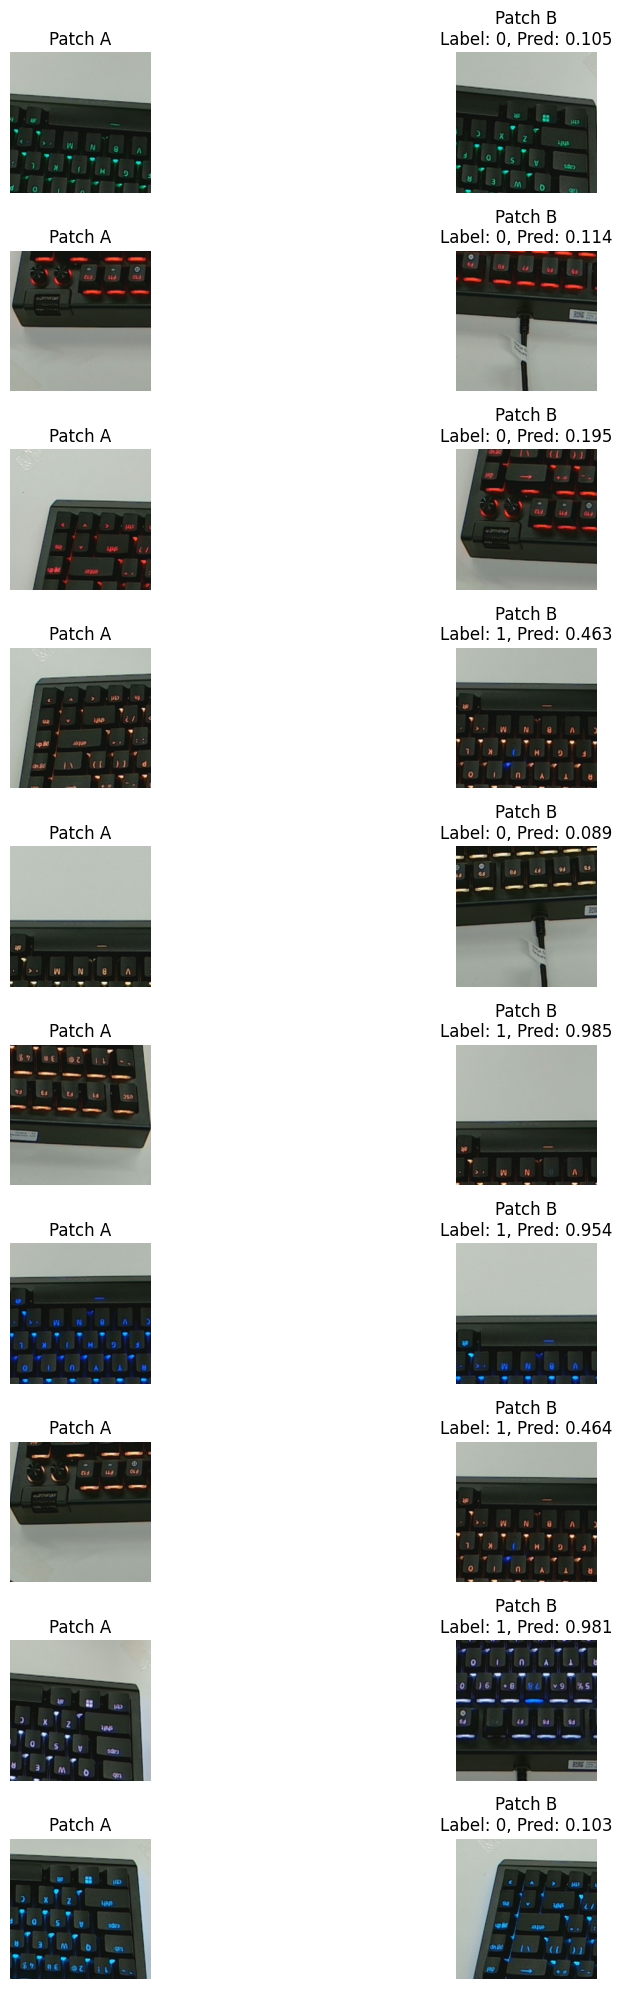

In [9]:

import matplotlib.pyplot as plt

def visualize_siamese_pairs(model, generator, num_samples=10):
    """Visualize a few Siamese pairs with predicted distances and labels."""
    [X1, X2], y_true = generator.__getitem__(0)  # get a batch
    y_pred = model.predict([X1, X2])

    plt.figure(figsize=(12, num_samples * 2))

    for i in range(num_samples):
        ax1 = plt.subplot(num_samples, 2, 2*i + 1)
        ax2 = plt.subplot(num_samples, 2, 2*i + 2)

        ax1.imshow(X1[i])
        ax1.set_title("Patch A")
        ax1.axis('off')

        ax2.imshow(X2[i])
        ax2.set_title(f"Patch B\nLabel: {y_true[i]}, Pred: {y_pred[i][0]:.3f}")
        ax2.axis('off')

    plt.tight_layout()
    plt.show()

# After training or loading your model
visualize_siamese_pairs(siamese_model, val_gen, num_samples=10)

In [10]:
for (x1_batch, x2_batch), y_batch in val_gen:
    preds = siamese_model.predict([x1_batch, x2_batch])
    print("Labels:", y_batch[:10])
    print("Preds :", preds[:10].flatten())
    break


1/1 [==============================] - 0s 26ms/step
Labels: [0 0 1 0 1 0 0 0 0 1]
Preds : [0.6618013  0.5587715  0.798497   0.10212373 0.8412779  0.10761627
 0.13827474 0.23850393 0.1084586  0.7703732 ]


# For Testing

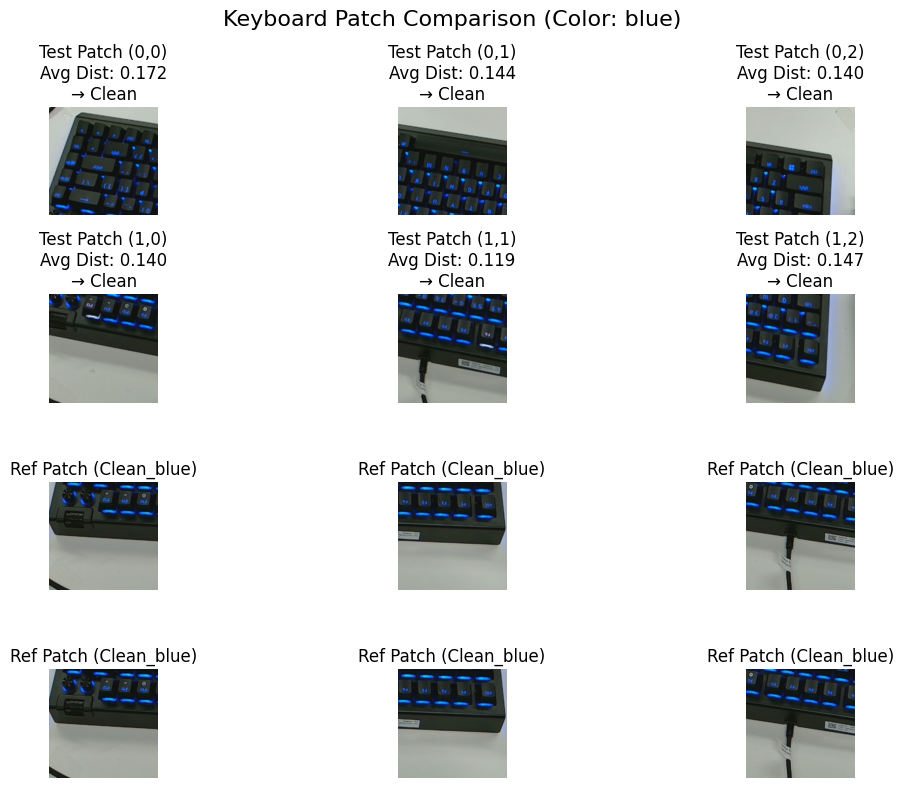


Final Keyboard Prediction: CLEAN


In [41]:
import numpy as np
import tensorflow as tf
import cv2
from pathlib import Path
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import matplotlib.pyplot as plt
import random
from PIL import Image

# === CONFIGURATION ===
img_size = 224
rows, cols = 2, 3
threshold = 0.5
color_group = "blue"

# === Load Trained Model ===
model = tf.keras.models.load_model("../models/siamese_model.h5")

# === Load Reference Clean Patches ===
ref_dir = Path.home() / "Documents" / "siamese_dataset" / "train" / "clean" / f"clean_{color_group}"
ref_paths = random.sample(list(ref_dir.glob("*.jpg")), k=5)
ref_imgs = np.array([img_to_array(load_img(p, target_size=(img_size, img_size))) / 255.0 for p in ref_paths])

# === Load Test Keyboard Image ===
keyboard_path = Path("../Robot/pictures/photo.jpg")

# Load using PIL (via Keras) for consistency
img_pil = load_img(keyboard_path)  # retains RGB by default
img = np.array(img_pil)  # Convert to numpy array

# === Patch extraction parameters ===
rows, cols = 2, 3
img_size = 224
h, w = img.shape[:2]
patch_h, patch_w = h // rows, w // cols

def extract_patches(img):
    patches = []
    for i in range(rows):
        for j in range(cols):
            y1, y2 = i * patch_h, (i + 1) * patch_h
            x1, x2 = j * patch_w, (j + 1) * patch_w
            patch = img[y1:y2, x1:x2]

            # Resize using PIL to match Keras training behavior
            patch_pil = Image.fromarray(patch).resize((img_size, img_size), resample=Image.BILINEAR)
            patch_array = img_to_array(patch_pil) / 255.0  # normalize
            patches.append(patch_array)
    return np.array(patches)

test_patches = extract_patches(img)


# === Visualize Pairs ===
fig, axes = plt.subplots(rows * 2, cols, figsize=(12, 8))
fig.suptitle(f"Keyboard Patch Comparison (Color: {color_group})", fontsize=16)
faulty_flags = []

for idx, patch in enumerate(test_patches):
    patch_input = np.expand_dims(patch, axis=0)
    dists = [model.predict([patch_input, np.expand_dims(ref, axis=0)], verbose=0)[0][0] for ref in ref_imgs]
    avg_dist = np.mean(dists)
    is_faulty = avg_dist > threshold
    faulty_flags.append(is_faulty)

    row, col = divmod(idx, cols)
    axes[row, col].imshow(patch)
    axes[row, col].axis("off")
    axes[row, col].set_title(f"Test Patch ({row},{col})\nAvg Dist: {avg_dist:.3f}\n→ {'Faulty' if is_faulty else 'Clean'}")

    axes[row + rows, col].imshow(ref_imgs[col])
    axes[row + rows, col].axis("off")
    axes[row + rows, col].set_title(f"Ref Patch (Clean_{color_group})")

plt.tight_layout()
plt.show()

print(f"\nFinal Keyboard Prediction: {'FAULTY' if any(faulty_flags) else 'CLEAN'}")


In [15]:
from pathlib import Path
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

def extract_images_from_folder(folder_path, img_size=224, max_images=None):
    """
    Loads and preprocesses images from a folder.

    Args:
        folder_path (str or Path): Path to folder containing .jpg images
        img_size (int): Target width and height
        max_images (int): Limit number of images (optional)

    Returns:
        np.ndarray: Array of shape (N, img_size, img_size, 3)
    """
    folder_path = Path(folder_path)
    image_paths = sorted(folder_path.glob("*.jpg"))
    if max_images:
        image_paths = image_paths[:max_images]

    images = []
    for path in image_paths:
        img = load_img(path, target_size=(img_size, img_size))
        arr = img_to_array(img) / 255.0  # Normalize
        images.append(arr)

    return np.array(images)

val_imgs = extract_images_from_folder(
    Path.home() / "Documents" / "siamese_dataset" / "Test",
    max_images=6
)

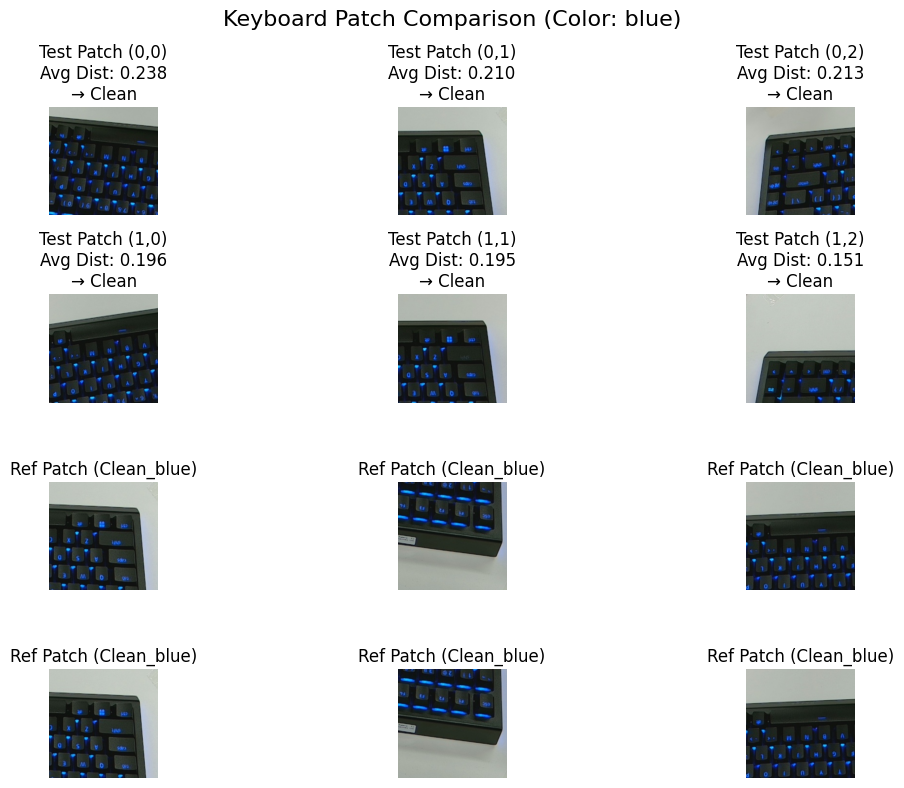


Final Keyboard Prediction: CLEAN


In [ ]:
import numpy as np
import tensorflow as tf
import cv2
from pathlib import Path
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import matplotlib.pyplot as plt
import random

# === CONFIGURATION ===
img_size = 224
rows, cols = 2, 3
threshold = 0.5
color_group = "blue"

# === Load Trained Model ===
model = tf.keras.models.load_model("../models/siamese_model.h5")

# === Load Reference Clean Patches ===
ref_dir = Path.home() / "Documents" / "siamese_dataset" / "train" / "clean" / f"clean_{color_group}"
ref_paths = random.sample(list(ref_dir.glob("*.jpg")), k=6)
ref_imgs = np.array([img_to_array(load_img(p, target_size=(img_size, img_size))) / 255.0 for p in ref_paths])

# === Visualize Pairs ===
fig, axes = plt.subplots(rows * 2, cols, figsize=(12, 8))
fig.suptitle(f"Keyboard Patch Comparison (Color: {color_group})", fontsize=16)
faulty_flags = []

for idx, patch in enumerate(val_imgs):
    np.array([img_to_array(load_img(p, target_size=(img_size, img_size))) / 255.0 for p in ref_paths])
    patch_input = np.expand_dims(patch, axis=0)
    dists = [model.predict([patch_input, np.expand_dims(ref, axis=0)], verbose=0)[0][0] for ref in ref_imgs]
    avg_dist = np.mean(dists)
    is_faulty = avg_dist > threshold
    faulty_flags.append(is_faulty)

    row, col = divmod(idx, cols)
    axes[row, col].imshow(patch)
    axes[row, col].axis("off")
    axes[row, col].set_title(f"Test Patch ({row},{col})\nAvg Dist: {avg_dist:.3f}\n→ {'Faulty' if is_faulty else 'Clean'}")

    axes[row + rows, col].imshow(ref_imgs[col])
    axes[row + rows, col].axis("off")
    axes[row + rows, col].set_title(f"Ref Patch (Clean_{color_group})")

plt.tight_layout()
plt.show()

print(f"\nFinal Keyboard Prediction: {'FAULTY' if any(faulty_flags) else 'CLEAN'}")

In [34]:
# Pull batch directly from val_gen
(x1, x2), y = next(iter(val_gen))

# Pick one pair known to be faulty
pred_val = model.predict([np.expand_dims(x1[2], 0), np.expand_dims(x2[2], 0)])
print("From val_gen (correct):", pred_val[0][0])

# Save that same image to disk and reload manually
from tensorflow.keras.preprocessing.image import array_to_img

array_to_img(x1[2]).save("x1_test.jpg")
array_to_img(x2[2]).save("x2_test.jpg")

# Now reload them using your manual pipeline
img1 = load_img("x1_test.jpg", target_size=(224, 224))
img2 = load_img("x2_test.jpg", target_size=(224, 224))

arr1 = img_to_array(img1) / 255.0
arr2 = img_to_array(img2) / 255.0

pred_test = model.predict([np.expand_dims(arr1, 0), np.expand_dims(arr2, 0)])
print("From test pipeline:", pred_test[0][0])


1/1 [==============================] - 0s 19ms/step
From val_gen (correct): 0.9810058
1/1 [==============================] - 0s 18ms/step
From test pipeline: 0.96534795


In [37]:
# Pull one batch from val_gen
(x1, x2), y = next(iter(val_gen))

# Find one clean-clean and one clean-faulty pair
for i in range(len(y)):
    pred = model.predict([np.expand_dims(x1[i], 0), np.expand_dims(x2[i], 0)], verbose=0)[0][0]
    print(f"Label: {y[i]}, Predicted Prob: {pred:.3f}")


Label: 0, Predicted Prob: 0.405
Label: 1, Predicted Prob: 0.379
Label: 0, Predicted Prob: 0.114
Label: 1, Predicted Prob: 0.832
Label: 0, Predicted Prob: 0.085
Label: 0, Predicted Prob: 0.161
Label: 1, Predicted Prob: 0.694
Label: 1, Predicted Prob: 0.983
Label: 0, Predicted Prob: 0.301
Label: 0, Predicted Prob: 0.361
Label: 0, Predicted Prob: 0.137
Label: 0, Predicted Prob: 0.245
Label: 1, Predicted Prob: 0.984
Label: 1, Predicted Prob: 0.199
Label: 0, Predicted Prob: 0.143
Label: 0, Predicted Prob: 0.214
Label: 0, Predicted Prob: 0.079
Label: 1, Predicted Prob: 0.847
Label: 1, Predicted Prob: 0.987
Label: 1, Predicted Prob: 0.799
Label: 1, Predicted Prob: 0.938
Label: 0, Predicted Prob: 0.262
Label: 0, Predicted Prob: 0.197
Label: 1, Predicted Prob: 0.178
Label: 1, Predicted Prob: 0.172
Label: 0, Predicted Prob: 0.132
Label: 1, Predicted Prob: 0.794
Label: 0, Predicted Prob: 0.302
Label: 0, Predicted Prob: 0.395
Label: 0, Predicted Prob: 0.143
Label: 1, Predicted Prob: 0.730
Label: 0

In [40]:
from tensorflow.keras.preprocessing.image import array_to_img, load_img, img_to_array

# Save the same pair to disk
array_to_img(x1[i]).save("img_a.jpg")
array_to_img(x2[i]).save("img_b.jpg")

# Reload and re-predict
img_a = img_to_array(load_img("img_a.jpg", target_size=(224, 224))) / 255.0
img_b = img_to_array(load_img("img_b.jpg", target_size=(224, 224))) / 255.0

pred_reloaded = model.predict([np.expand_dims(img_a, 0), np.expand_dims(img_b, 0)], verbose=0)[0][0]
print(f"Reloaded pred: {pred_reloaded:.3f}")


Reloaded pred: 0.145


In [46]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Step 1: Load 1 clean reference image from your training set
ref_path = sorted(Path(train_clean_dir / f"clean_{color_group}").glob("*.jpg"))[0]
ref_patch = img_to_array(load_img(ref_path, target_size=(224, 224))) / 255.0
ref_patch = np.expand_dims(ref_patch, axis=0) 

# Step 2: Get one batch from validation generator
(x1, x2), y = next(iter(val_gen))

# Save to disk
array_to_img(x2[0]).save("check_patch.jpg")

# Reload using your manual pipeline
reloaded = img_to_array(load_img("check_patch.jpg", target_size=(224, 224))) / 255.0

# Compare tensors directly
print("Max diff:", np.max(np.abs(x2[0] - reloaded)))

# Step 3: Compare reference clean patch to each val x2[i]
for i in range(len(y)):
    test_patch = np.expand_dims(x2[i], axis=0)
    pred = model.predict([ref_patch, test_patch], verbose=0)[0][0]
    print(f"Index: {i} | Label: {y[i]} | Predicted Dissimilarity: {pred:.3f}")

# Step 3: Compare reference clean patch to each val x2[i]
for i in range(len(y)):
    test_patch = np.expand_dims(x2[i], axis=0)
    pred = model.predict([ref_patch, np.expand_dims(reloaded, 0)], verbose=0)[0][0]
    print(f"Index: {i} | Label: {y[i]} | Predicted Dissimilarity: {pred:.3f}")

# # Predict on original
# pred_from_gen = model.predict([np.expand_dims(x1[0], 0), np.expand_dims(x2[0], 0)], verbose=0)

# # Predict on reloaded
# pred_from_file = model.predict([np.expand_dims(x1[0], 0), np.expand_dims(reloaded, 0)], verbose=0)

# print("Pred (val_gen):", pred_from_gen[0][0])
# print("Pred (from reload):", pred_from_file[0][0])


Max diff: 0.13333333
Index: 0 | Label: 1 | Predicted Dissimilarity: 0.240
Index: 1 | Label: 1 | Predicted Dissimilarity: 0.774
Index: 2 | Label: 1 | Predicted Dissimilarity: 0.462
Index: 3 | Label: 1 | Predicted Dissimilarity: 0.504
Index: 4 | Label: 1 | Predicted Dissimilarity: 0.874
Index: 5 | Label: 1 | Predicted Dissimilarity: 0.797
Index: 6 | Label: 1 | Predicted Dissimilarity: 0.397
Index: 7 | Label: 1 | Predicted Dissimilarity: 0.477
Index: 8 | Label: 0 | Predicted Dissimilarity: 0.118
Index: 9 | Label: 0 | Predicted Dissimilarity: 0.212
Index: 10 | Label: 0 | Predicted Dissimilarity: 0.158
Index: 11 | Label: 1 | Predicted Dissimilarity: 0.985
Index: 12 | Label: 0 | Predicted Dissimilarity: 0.218
Index: 13 | Label: 0 | Predicted Dissimilarity: 0.261
Index: 14 | Label: 1 | Predicted Dissimilarity: 0.852
Index: 15 | Label: 0 | Predicted Dissimilarity: 0.580
Index: 16 | Label: 1 | Predicted Dissimilarity: 0.821
Index: 17 | Label: 1 | Predicted Dissimilarity: 0.354
Index: 18 | Label

In [48]:
from pathlib import Path
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

def extract_images_from_folder(folder_path, img_size=224, max_images=None):
    """
    Loads and preprocesses images from a folder.

    Args:
        folder_path (str or Path): Path to folder containing .jpg images
        img_size (int): Target width and height
        max_images (int): Limit number of images (optional)

    Returns:
        np.ndarray: Array of shape (N, img_size, img_size, 3)
    """
    folder_path = Path(folder_path)
    image_paths = sorted(folder_path.glob("*.jpg"))
    if max_images:
        image_paths = image_paths[:max_images]

    images = []
    for path in image_paths:
        img = load_img(path, target_size=(img_size, img_size))
        arr = img_to_array(img) / 255.0  # Normalize
        images.append(arr)

    return np.array(images)

class InferenceGenerator(Sequence):
    def __init__(self, val_imgs, ref_patches):
        self.val_imgs = val_imgs
        self.ref_patches = ref_patches

    def __len__(self):
        return len(self.val_imgs)

    def __getitem__(self, index):
        val = np.expand_dims(self.val_imgs[index], 0)  # (1, 224, 224, 3)
        ref = np.expand_dims(self.ref_patches[index % len(self.ref_patches)], 0)
        
        # Return as a tuple of arrays
        return ([val, ref], np.array([0]))  # Dummy label just for shape

ref_paths = sorted((train_clean_dir / f"clean_{color_group}").glob("*.jpg"))[:5]
ref_imgs = np.array([
    img_to_array(load_img(p, target_size=(224, 224))) / 255.0
    for p in ref_paths
])

val_imgs = extract_images_from_folder(
    Path.home() / "Documents" / "siamese_dataset" / "Test",
    max_images=6
)

test_gen = InferenceGenerator(val_imgs, ref_imgs)
preds = model.predict(test_gen)

6/6 [==============================] - 1s 25ms/step


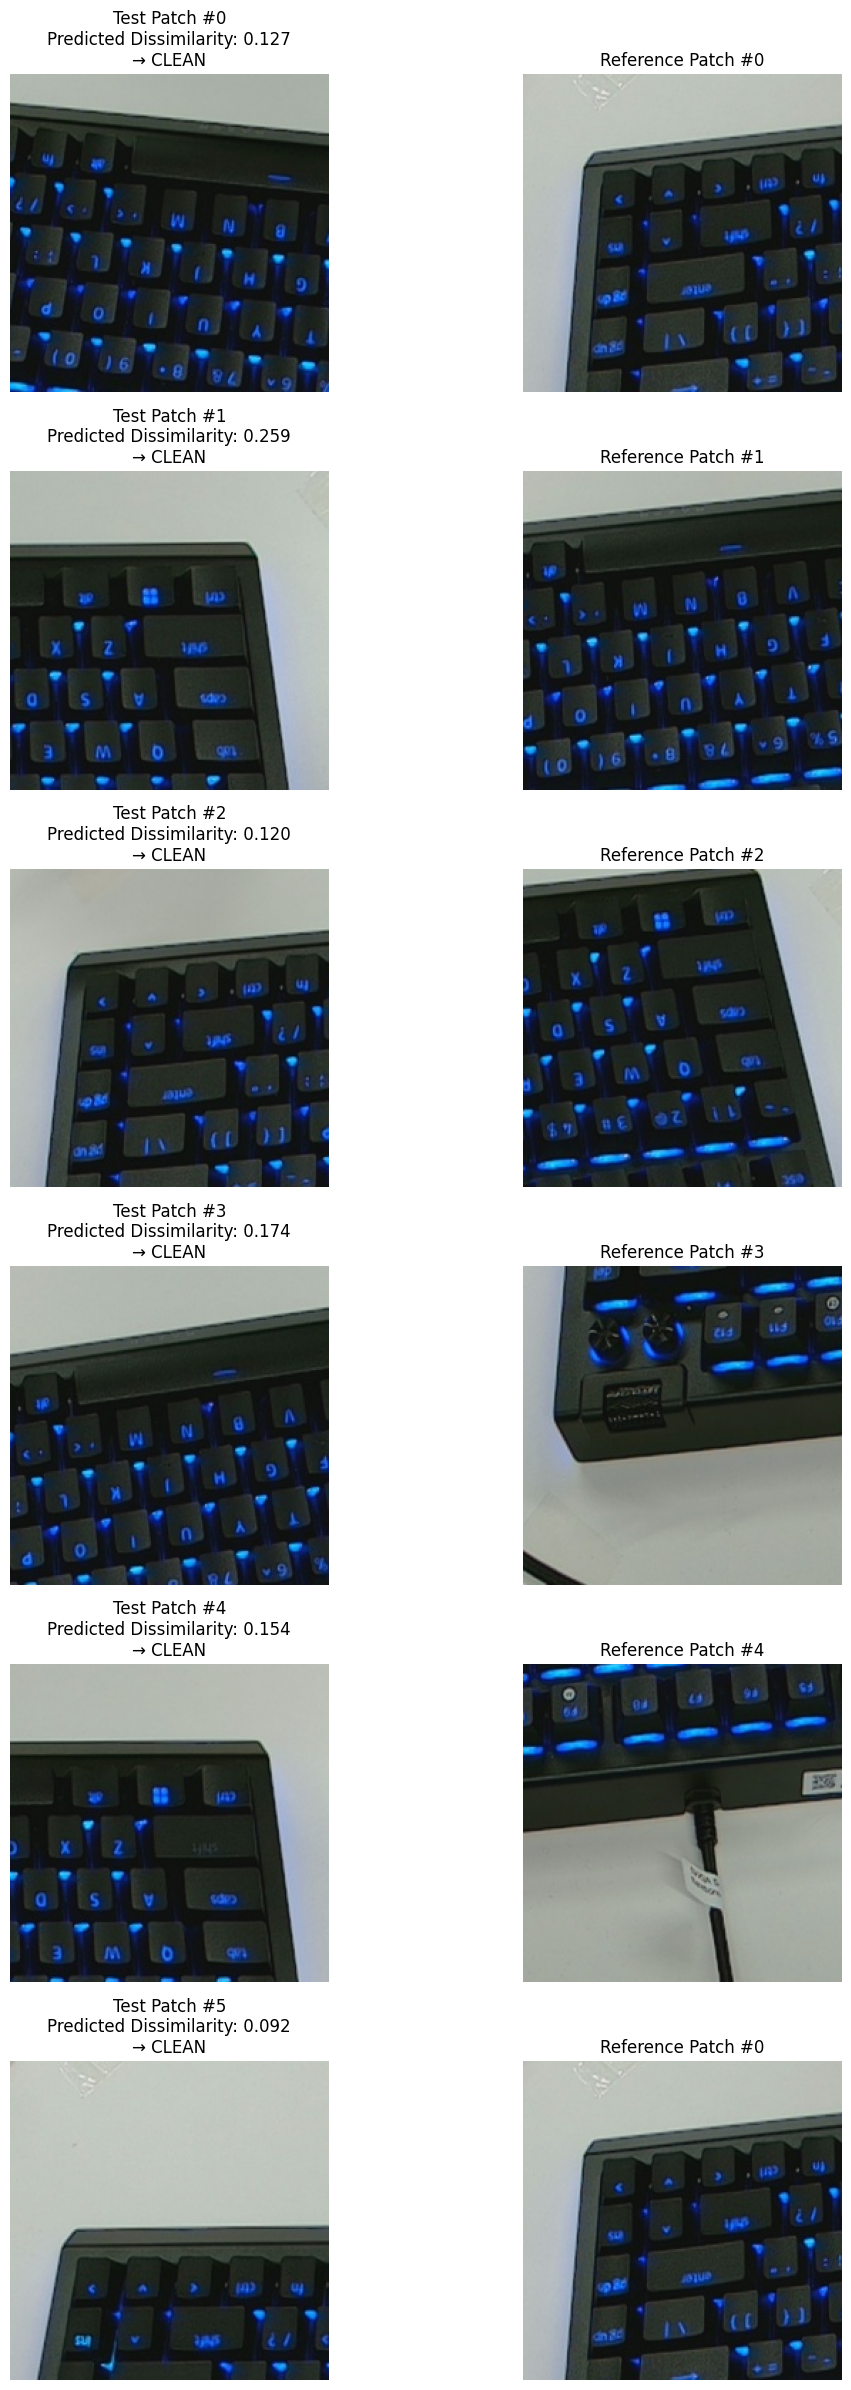

In [49]:
import matplotlib.pyplot as plt

# Visualize the results
num_patches = len(val_imgs)
plt.figure(figsize=(12, 4 * num_patches))

for i in range(num_patches):
    val_img = val_imgs[i]
    ref_img = ref_imgs[i % len(ref_imgs)]
    pred_score = preds[i][0]
    
    plt.subplot(num_patches, 2, 2 * i + 1)
    plt.imshow(val_img)
    plt.title(f"Test Patch #{i}\nPredicted Dissimilarity: {pred_score:.3f}\n→ {'FAULTY' if pred_score > 0.5 else 'CLEAN'}")
    plt.axis("off")
    
    plt.subplot(num_patches, 2, 2 * i + 2)
    plt.imshow(ref_img)
    plt.title(f"Reference Patch #{i % len(ref_imgs)}")
    plt.axis("off")

plt.tight_layout()
plt.show()
